Step1

In [2]:
import pandas as pd
import glob
import os
import sys

# Define directories
data_dir = r"C:\Users\Ashwa\Ash_projects\Indigo_Research\BACIDataset1995"
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

# Step 1: Load and Aggregate BACI Data
# File pattern for the user's dataset
baci_files = sorted(glob.glob(os.path.join(data_dir, "BACI_HS92_Y*_V202601.csv")))
print(f"Found {len(baci_files)} BACI files.")

if not baci_files:
    print("No BACI files found! Please check the dataset path.")
    sys.exit(1)

# Only process years 1995-2022 as per plan logic?
# The plan mentions 1995–2022. Let's filter if needed, 
# although having more years (up to 2024) might be better. 
# Let's use all available files to be comprehensive.

df_list = []
for file in baci_files:
    print(f"Loading {os.path.basename(file)}...")
    df = pd.read_csv(file)
    # Aggregate: X_cpt = sum over j (all importers)
    # Columns in BACI are t, i, j, k, v, q
    # We want to group by year (t), exporter (i), product (k)
    exports_year = df.groupby(['t', 'i', 'k'])['v'].sum().reset_index()
    exports_year.columns = ['year', 'country', 'product', 'value']
    df_list.append(exports_year)

# Concatenate all years
print("Concatenating aggregated data...")
exports = pd.concat(df_list, ignore_index=True)

# Save intermediate result
output_file = os.path.join(output_dir, "exports_cpt.csv")
exports.to_csv(output_file, index=False)

# Validation Statistics
print("\nValidation Statistics for Step 1:")
print(f"Output file: {output_file}")
print(f"File created: {os.path.exists(output_file)}")
print(f"Total rows: {len(exports)}")
print(f"Year range: {exports['year'].min()} to {exports['year'].max()}")
print(f"Unique countries: {exports['country'].nunique()}")
print(f"Unique products: {exports['product'].nunique()}")
print(f"Total trade value: {exports['value'].sum():,.0f}")


Found 30 BACI files.
Loading BACI_HS92_Y1995_V202601.csv...
Loading BACI_HS92_Y1996_V202601.csv...
Loading BACI_HS92_Y1997_V202601.csv...
Loading BACI_HS92_Y1998_V202601.csv...
Loading BACI_HS92_Y1999_V202601.csv...
Loading BACI_HS92_Y2000_V202601.csv...
Loading BACI_HS92_Y2001_V202601.csv...
Loading BACI_HS92_Y2002_V202601.csv...
Loading BACI_HS92_Y2003_V202601.csv...
Loading BACI_HS92_Y2004_V202601.csv...
Loading BACI_HS92_Y2005_V202601.csv...
Loading BACI_HS92_Y2006_V202601.csv...
Loading BACI_HS92_Y2007_V202601.csv...
Loading BACI_HS92_Y2008_V202601.csv...
Loading BACI_HS92_Y2009_V202601.csv...
Loading BACI_HS92_Y2010_V202601.csv...
Loading BACI_HS92_Y2011_V202601.csv...
Loading BACI_HS92_Y2012_V202601.csv...
Loading BACI_HS92_Y2013_V202601.csv...
Loading BACI_HS92_Y2014_V202601.csv...
Loading BACI_HS92_Y2015_V202601.csv...
Loading BACI_HS92_Y2016_V202601.csv...
Loading BACI_HS92_Y2017_V202601.csv...
Loading BACI_HS92_Y2018_V202601.csv...
Loading BACI_HS92_Y2019_V202601.csv...
Load

Step 2

In [ ]:
import pandas as pd
import torch
import os

# Define directories
output_dir = "data"
input_file = os.path.join(output_dir, "exports_cpt.csv")
output_file = os.path.join(output_dir, "rca_cpt.csv")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Starting Step 2 (CUDA Accelerated): Computing RCA Matrix using {device}...")

if not os.path.exists(input_file):
    print(f"Error: {input_file} not found. Did you run Step 1?")
    exit(1)

# Load aggregated exports
df = pd.read_csv(input_file)

# Move data to GPU using PyTorch for massive speedup in math
# We'll compute the totals using grouping logic on the CPU briefly 
# because it's easier with pandas, then compute the division on GPU.

print("Calculating totals on CPU/GPU...")
df['country_total'] = df.groupby(['year', 'country'])['value'].transform('sum')
df['product_total'] = df.groupby(['year', 'product'])['value'].transform('sum')
df['world_total'] = df.groupby('year')['value'].transform('sum')

# Convert to tensors for the division (accelerated on GPU)
val_t = torch.tensor(df['value'].values, dtype=torch.float32, device=device)
c_total_t = torch.tensor(df['country_total'].values, dtype=torch.float32, device=device)
p_total_t = torch.tensor(df['product_total'].values, dtype=torch.float32, device=device)
w_total_t = torch.tensor(df['world_total'].values, dtype=torch.float32, device=device)

print("Running RCA division on CUDA...")
# RCA = (X_cpt / CountryTotal) / (ProductTotal / WorldTotal)
rca_t = (val_t / (c_total_t + 1e-8)) / ((p_total_t + 1e-8) / w_total_t)

# Move back to CPU and save
df['rca'] = rca_t.cpu().numpy()

# Drop intermediate columns
df = df[['year', 'country', 'product', 'value', 'rca']]

# Save RCA matrix
df.to_csv(output_file, index=False)

# Validation Statistics
print("\nValidation Statistics for Step 2:")
print(f"Output file: {output_file}")
print(f"Max RCA: {df['rca'].max():.4f}")
print(f"RCA >= 1 entries: {(df['rca'] >= 1).sum()}")
print("Step 2 Finished.")


Starting Step 2 (CUDA Accelerated): Computing RCA Matrix using cuda...
Calculating totals on CPU/GPU...
Running RCA division on CUDA...

Validation Statistics for Step 2:
Output file: data\rca_cpt.csv
Max RCA: 2443744.0000
RCA >= 1 entries: 2855403
Step 2 Finished.


In [ ]:
import pandas as pd
import torch
import os

# Define directories
output_dir = "data"
input_file = os.path.join(output_dir, "rca_cpt.csv")
output_file = os.path.join(output_dir, "M_cpt_smoothed.csv")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Starting Step 3 (CUDA Accelerated): Smoothing and Binarizing...")

if not os.path.exists(input_file):
    print(f"Error: {input_file} not found. Did you run Step 2?")
    exit(1)

# Load RCA data
df = pd.read_csv(input_file)

# 1. Map IDs to fixed indices for Tensor operations
years = sorted(df['year'].unique())
countries = sorted(df['country'].unique())
products = sorted(df['product'].unique())

year_map = {y: i for i, y in enumerate(years)}
country_map = {c: i for i, c in enumerate(countries)}
product_map = {p: i for i, p in enumerate(products)}

# 2. Create a sparse representation using a 3D Binary Tensor: [Years, Countries, Products]
print(f"Allocating 3D Tensor: [{len(years)}, {len(countries)}, {len(products)}] on {device}")
# M_binary: initialized to zero
M_binary = torch.zeros((len(years), len(countries), len(products)), dtype=torch.float32, device=device)

# Fill indices where RCA >= 1
mask = df['rca'] >= 1.0
active_df = df[mask]

# Extract indices for mapping
idx_y = torch.tensor(active_df['year'].map(year_map).values, device=device)
idx_c = torch.tensor(active_df['country'].map(country_map).values, device=device)
idx_p = torch.tensor(active_df['product'].map(product_map).values, device=device)

# Set RCA=1 markers in tensor
M_binary[idx_y, idx_c, idx_p] = 1.0

# 3. Apply 3-Year CAUSAL Rolling Window Sum (CUDA Accelerated)
# IMPORTANT — leakage fix: we must use a TRAILING window [t-2, t-1, t],
# NOT a centered window [t-1, t, t+1]. A centered conv1d(padding=1) leaks
# year t+1 into position t, which are the same years used to build labels.
# Fix: pad=2 on the LEFT only (causal padding), then strip the 2 extra
# output positions on the RIGHT that were produced by the right-side zeros.
print("Applying 3-year CAUSAL rolling window sum (no future leakage)...")
# Reshape to [C*P, 1, Y] for 1D convolution across the Year axis
M_reshaped = M_binary.permute(1, 2, 0).reshape(-1, 1, len(years))

# Causal padding: pad 2 zeros on the left, 0 on the right
M_padded = torch.nn.functional.pad(M_reshaped, (2, 0))
kernel = torch.ones((1, 1, 3), device=device)
# No extra padding in conv1d itself; the left pad gives us the trailing window
M_sum = torch.nn.functional.conv1d(M_padded, kernel, padding=0)
# M_sum now has the same length as M_reshaped (years); each position t
# contains sum(t-2, t-1, t) — purely historic, zero leakage.

# M=1 if sum >= 2 (RCA >= 1 in at least 2 out of 3 trailing years)
M_smoothed = (M_sum >= 2.0).float().reshape(len(countries), len(products), len(years)).permute(2, 0, 1)

# 4. Filter back to sparse long-format and save
# Find indices where M_smoothed == 1
nonzero_indices = torch.nonzero(M_smoothed)
print(f"Found {len(nonzero_indices)} edges with RCA >= 1 (smoothed).")

# Convert back to DataFrame
edge_list = {
    'year': [years[i] for i in nonzero_indices[:, 0].cpu()],
    'country': [countries[i] for i in nonzero_indices[:, 1].cpu()],
    'product': [products[i] for i in nonzero_indices[:, 2].cpu()],
    'M': [1] * len(nonzero_indices)
}

edges_df = pd.DataFrame(edge_list)
edges_df.to_csv(output_file, index=False)

# Validation Statistics
print("\nValidation Statistics for Step 3:")
print(f"Output: {output_file}")
print(f"Total smoothed edges: {len(edges_df)}")
print("Smoothing (CUDA) Finished.")


Starting Step 3 (CUDA Accelerated): Smoothing and Binarizing...
Allocating 3D Tensor: [30, 233, 5018] on cuda
Applying 3-year CAUSAL rolling window sum (no future leakage)...
Found 2479680 edges with RCA >= 1 (smoothed).

Validation Statistics for Step 3:
Output: data\M_cpt_smoothed.csv
Total smoothed edges: 2479680
Smoothing (CUDA) Finished.


Step 4

In [ ]:
import pandas as pd
import torch
import os
import random

# Define directories
output_dir = "data"
input_file = os.path.join(output_dir, "M_cpt_smoothed.csv")
output_file = os.path.join(output_dir, "labels_h5.csv")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Starting Step 4 (CUDA Accelerated): Generating Prediction Labels (h=5)...")

if not os.path.exists(input_file):
    print(f"Error: {input_file} not found. Did you run Step 3?")
    exit(1)

# Load smoothed edges (only where M=1)
df = pd.read_csv(input_file)

# We'll re-convert to a 3D Tensor [Years, Countries, Products] on GPU
years = sorted(df['year'].unique())
countries = sorted(df['country'].unique())
products = sorted(df['product'].unique())

year_map = {y: i for i, y in enumerate(years)}
country_map = {c: i for i, c in enumerate(countries)}
product_map = {p: i for i, p in enumerate(products)}

print(f"Allocating 3D Tensor on {device}...")
M = torch.zeros((len(years), len(countries), len(products)), dtype=torch.uint8, device=device)

# Fill indices
idx_y = torch.tensor(df['year'].map(year_map).values, device=device)
idx_c = torch.tensor(df['country'].map(country_map).values, device=device)
idx_p = torch.tensor(df['product'].map(product_map).values, device=device)
M[idx_y, idx_c, idx_p] = 1

# Generate labels (h=5, horizon target t+5, sustained at t+6)
h = 5
total_years = len(years)
# We can only generate labels for years t where t+h+1 < total_years
limit = total_years - h - 1

print(f"Generating labels for {limit} years on CUDA...")

# 1. Slice Tensors for t, t+5, t+6
# Masks [T_valid, C, P]
M_t = M[:limit]
M_t5 = M[h:limit+h]
M_t6 = M[h+1:limit+h+1]

# 2. Extract Positive Indices (new sustained activation)
positives_mask = (M_t == 0) & (M_t5 == 1) & (M_t6 == 1)
pos_indices = torch.nonzero(positives_mask)
print(f"Found {len(pos_indices)} positive instances.")

# 3. Extract Negative Indices (stay 0)
negatives_mask = (M_t == 0) & (M_t5 == 0)
# Instead of keeping all (millions), we'll sample negative indices
# For efficiency, we'll sub-sample directly on GPU if possible
# Or just get all and sample in pandas
neg_indices = torch.nonzero(negatives_mask)
print(f"Total possible negative pool: {len(neg_indices)} instances.")

# --- Sampling ---
# We want roughly 5x negatives relative to positives (neg_ratio=5).
# With ~3% positive rate, a 2:1 ratio under-represents negatives; using 5:1
# gives the model a realistic training distribution without collapsing to all-zero.
target_neg = min(len(neg_indices), 5 * len(pos_indices))
print(f"Sampling {target_neg} negatives to balance classes...")

# GPU sampling indices
sample_idx = torch.randperm(len(neg_indices), device=device)[:target_neg]
neg_sampled = neg_indices[sample_idx]

# --- Combine and Convert back ---
print("Converting back to long format and saving...")
all_labels = []

# Positives
pos_df = pd.DataFrame({
    'year': [years[i] for i in pos_indices[:, 0].cpu()],
    'country': [countries[i] for i in pos_indices[:, 1].cpu()],
    'product': [products[i] for i in pos_indices[:, 2].cpu()],
    'label': 1
})

# Negatives
neg_df = pd.DataFrame({
    'year': [years[i] for i in neg_sampled[:, 0].cpu()],
    'country': [countries[i] for i in neg_sampled[:, 1].cpu()],
    'product': [products[i] for i in neg_sampled[:, 2].cpu()],
    'label': 0
})

final_df = pd.concat([pos_df, neg_df], ignore_index=True)
final_df.to_csv(output_file, index=False)

# Validation Statistics
print("\nValidation Statistics for Step 4:")
print(f"Output: {output_file}")
print(f"Positive samples: {len(pos_df)}")
print(f"Negative samples: {len(neg_df)}")
print("Label generation (CUDA) Finished.")


Starting Step 4 (CUDA Accelerated): Generating Prediction Labels (h=5)...
Allocating 3D Tensor on cuda...
Generating labels for 23 years on CUDA...
Found 501971 positive instances.
Total possible negative pool: 24298573 instances.
Sampling 2509855 negatives to balance classes...
Converting back to long format and saving...

Validation Statistics for Step 4:
Output: data\labels_h5.csv
Positive samples: 501971
Negative samples: 2509855
Label generation (CUDA) Finished.


step 5

In [ ]:
import pandas as pd
import numpy as np
import os

# Define directories
output_dir = "data"
input_file = os.path.join(output_dir, "rca_cpt.csv")
country_output = os.path.join(output_dir, "country_features.csv")
product_output = os.path.join(output_dir, "product_features.csv")

print(f"Starting Step 5: Creating Node Features...")

if not os.path.exists(input_file):
    print(f"Error: {input_file} not found. Did you run Step 2?")
    exit(1)

# Load RCA aggregated exports
exports = pd.read_csv(input_file)

# Country Features per year
print("Creating country features per year...")
country_features = []
countries = sorted(exports['country'].unique())
years = sorted(exports['year'].unique())

for year in years:
    year_data = exports[exports['year'] == year]
    # Total export value (log scale) per country
    c_totals = year_data.groupby('country')['value'].sum()
    # Number of products with RCA >= 1
    c_rca_count = year_data[year_data['rca'] >= 1].groupby('country').size()
    # Average RCA across all products
    c_avg_rca = year_data.groupby('country')['rca'].mean()
    # Max RCA
    c_max_rca = year_data.groupby('country')['rca'].max()

    for c in countries:
        features = {
            'year': year,
            'country': c,
            'log_export': np.log1p(c_totals.get(c, 0)),
            'n_products': c_rca_count.get(c, 0),
            'avg_rca': c_avg_rca.get(c, 0),
            'max_rca': c_max_rca.get(c, 0),
        }
        country_features.append(features)

country_feat_df = pd.DataFrame(country_features)

# Normalize country features (z-score per year)
print("Normalizing country features...")
for col in ['log_export', 'n_products', 'avg_rca', 'max_rca']:
    country_feat_df[col] = country_feat_df.groupby('year')[col].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-8)
    )

country_feat_df.to_csv(country_output, index=False)

# Product Features per year
print("Creating product features per year...")
product_features = []
products = sorted(exports['product'].unique())

for year in years:
    year_data = exports[exports['year'] == year]
    # World export value for this product
    p_totals = year_data.groupby('product')['value'].sum()
    # Ubiquity: count countries with RCA >= 1
    p_ubiquity = year_data[year_data['rca'] >= 1].groupby('product').size()
    # Average RCA across countries for this product
    p_avg_rca = year_data.groupby('product')['rca'].mean()

    for p in products:
        features = {
            'year': year,
            'product': p,
            'log_world_export': np.log1p(p_totals.get(p, 0)),
            'ubiquity': p_ubiquity.get(p, 0),
            'avg_rca': p_avg_rca.get(p, 0),
        }
        product_features.append(features)

product_feat_df = pd.DataFrame(product_features)

# Normalize product features (z-score per year)
print("Normalizing product features...")
for col in ['log_world_export', 'ubiquity', 'avg_rca']:
    product_feat_df[col] = product_feat_df.groupby('year')[col].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-8)
    )

product_feat_df.to_csv(product_output, index=False)

# Validation Statistics
print("\nValidation Statistics for Step 5:")
print(f"Country Features: {len(country_feat_df)} rows, saved to {country_output}")
print(f"Product Features: {len(product_feat_df)} rows, saved to {product_output}")
print(f"Unique features (country): {['log_export', 'n_products', 'avg_rca', 'max_rca']}")
print(f"Unique features (product): {['log_world_export', 'ubiquity', 'avg_rca']}")


Starting Step 5: Creating Node Features...


Creating country features per year...
Normalizing country features...
Creating product features per year...
Normalizing product features...

Validation Statistics for Step 5:
Country Features: 6990 rows, saved to data\country_features.csv
Product Features: 150540 rows, saved to data\product_features.csv
Unique features (country): ['log_export', 'n_products', 'avg_rca', 'max_rca']
Unique features (product): ['log_world_export', 'ubiquity', 'avg_rca']


Step 6

In [ ]:
import pandas as pd
import torch
import pickle
import os

# Define directories
output_dir = "data"
input_file = os.path.join(output_dir, "M_cpt_smoothed.csv")
edge_output = os.path.join(output_dir, "edge_index_by_year.pt")
country_map_output = os.path.join(output_dir, "country_mapping.pkl")
product_map_output = os.path.join(output_dir, "product_mapping.pkl")

print(f"Starting Step 6: Building Temporal Graph Snapshots...")

if not os.path.exists(input_file):
    print(f"Error: {input_file} not found. Did you run Step 3?")
    exit(1)

# Load edges (M=1)
edges = pd.read_csv(input_file)

# Create integer mappings for countries and products
# (Crucial: These mappings must be consistent across all steps and years)
print("Creating node mappings...")
country_list = sorted(edges['country'].unique())
product_list = sorted(edges['product'].unique())

country_to_idx = {c: i for i, c in enumerate(country_list)}
product_to_idx = {p: i for i, p in enumerate(product_list)}

idx_to_country = {i: c for c, i in country_to_idx.items()}
idx_to_product = {i: p for p, i in product_to_idx.items()}

# Save mappings
print(f"Saving mappings to {country_map_output} and {product_map_output}...")
with open(country_map_output, "wb") as f:
    pickle.dump({'to_idx': country_to_idx, 'to_name': idx_to_country}, f)
with open(product_map_output, "wb") as f:
    pickle.dump({'to_idx': product_to_idx, 'to_name': idx_to_product}, f)

# Build edge_index per year
# edge_index: [2, num_edges] for source (country) and target (product)
print("Building edge indexes per year...")
edge_index_by_year = {}
years = sorted(edges['year'].unique())

for year in years:
    year_edges = edges[edges['year'] == year]
    
    # Convert to integer indices
    country_idx = year_edges['country'].map(country_to_idx).values
    product_idx = year_edges['product'].map(product_to_idx).values
    
    # Edge index: [2, num_edges]
    edge_index = torch.tensor([country_idx, product_idx], dtype=torch.long)
    edge_index_by_year[year] = edge_index

# Save as .pt file
print(f"Saving edge indexes to {edge_output}...")
torch.save(edge_index_by_year, edge_output)

# Validation Statistics
print("\nValidation Statistics for Step 6:")
print(f"Output: {edge_output}")
print(f"Total years processed: {len(edge_index_by_year)}")
print(f"Num countries: {len(country_to_idx)}")
print(f"Num products: {len(product_to_idx)}")
sample_year = years[0]
print(f"Snapshot edges (year {sample_year}): {edge_index_by_year[sample_year].shape[1]}")


Starting Step 6: Building Temporal Graph Snapshots...
Creating node mappings...
Saving mappings to data\country_mapping.pkl and data\product_mapping.pkl...
Building edge indexes per year...


C:\Users\Ashwa\AppData\Local\Temp\ipykernel_22604\561026400.py:55: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  edge_index = torch.tensor([country_idx, product_idx], dtype=torch.long)


Saving edge indexes to data\edge_index_by_year.pt...

Validation Statistics for Step 6:
Output: data\edge_index_by_year.pt
Total years processed: 29
Num countries: 233
Num products: 5018
Snapshot edges (year 1996): 64896


Step 7

In [ ]:
import pandas as pd
import torch
import pickle
import os

# Define directories
output_dir = "data"
country_feat_file = os.path.join(output_dir, "country_features.csv")
product_feat_file = os.path.join(output_dir, "product_features.csv")
country_map_file = os.path.join(output_dir, "country_mapping.pkl")
product_map_file = os.path.join(output_dir, "product_mapping.pkl")

country_x_output = os.path.join(output_dir, "country_x_by_year.pt")
product_x_output = os.path.join(output_dir, "product_x_by_year.pt")

print(f"Starting Step 7: Creating Node Feature Tensors...")

if not all(os.path.exists(f) for f in [country_feat_file, product_feat_file, country_map_file, product_map_file]):
    print("Error: Required input files not found. Did you run previous steps?")
    exit(1)

# Load features and mappings
country_feat = pd.read_csv(country_feat_file)
product_feat = pd.read_csv(product_feat_file)

with open(country_map_file, "rb") as f:
    country_map = pickle.load(f)
with open(product_map_file, "rb") as f:
    product_map = pickle.load(f)

# Sort based on indices to ensure tensors match edge index indices
country_x_by_year = {}
product_x_by_year = {}

years = sorted(country_feat['year'].unique())

for year in years:
    # Country features for this year
    # We must ensure that row 'i' of our tensor is for country with index 'i'
    year_country = country_feat[country_feat['year'] == year].copy()
    year_country['idx'] = year_country['country'].map(country_map['to_idx'] or -1)
    # Filter out any that weren't in the mapping (though they should all be there)
    year_country = year_country.sort_values('idx')
    
    # Feature columns: log_export, n_products, avg_rca, max_rca
    country_x = torch.tensor(
        year_country[['log_export', 'n_products', 'avg_rca', 'max_rca']].values,
        dtype=torch.float
    )
    country_x_by_year[year] = country_x
    
    # Product features for this year
    year_product = product_feat[product_feat['year'] == year].copy()
    year_product['idx'] = year_product['product'].map(product_map['to_idx'] or -1)
    year_product = year_product.sort_values('idx')
    
    # Feature columns: log_world_export, ubiquity, avg_rca
    product_x = torch.tensor(
        year_product[['log_world_export', 'ubiquity', 'avg_rca']].values,
        dtype=torch.float
    )
    product_x_by_year[year] = product_x

# Save
print(f"Saving feature tensors to {country_x_output} and {product_x_output}...")
torch.save(country_x_by_year, country_x_output)
torch.save(product_x_by_year, product_x_output)

# Validation Statistics
print("\nValidation Statistics for Step 7:")
print(f"Num years: {len(years)}")
sample_year = years[0]
print(f"Country feature shape (year {sample_year}): {country_x_by_year[sample_year].shape}")
print(f"Product feature shape (year {sample_year}): {product_x_by_year[sample_year].shape}")


Starting Step 7: Creating Node Feature Tensors...
Saving feature tensors to data\country_x_by_year.pt and data\product_x_by_year.pt...

Validation Statistics for Step 7:
Num years: 30
Country feature shape (year 1995): torch.Size([233, 4])
Product feature shape (year 1995): torch.Size([5018, 3])


Step 8

In [ ]:
import pandas as pd
import os

# Define directories
output_dir = "data"
labels_file = os.path.join(output_dir, "labels_h5.csv")

train_output = os.path.join(output_dir, "train_labels.csv")
val_output = os.path.join(output_dir, "val_labels.csv")
test_output = os.path.join(output_dir, "test_labels.csv")

print(f"Starting Step 8: Splitting Into Train/Validation/Test Windows...")

if not os.path.exists(labels_file):
    print(f"Error: {labels_file} not found. Did you run Step 4?")
    exit(1)

# Load labels
labels = pd.read_csv(labels_file)

# Split according to plan:
# Training: up to 2012
# Validation: 2013
# Test: 2015
train_labels = labels[labels['year'].between(2000, 2012)]
val_labels = labels[labels['year'] == 2013]
test_labels = labels[labels['year'] == 2015]

# Save split labels
print(f"Saving splits to {train_output}, {val_output}, and {test_output}...")
train_labels.to_csv(train_output, index=False)
val_labels.to_csv(val_output, index=False)
test_labels.to_csv(test_output, index=False)

# Validation Statistics
print("\nValidation Statistics for Step 8:")
print(f"Train labels (2000-2012): {len(train_labels)} rows, balanced.")
print(f"Val labels (2013): {len(val_labels)} rows.")
print(f"Test labels (2015): {len(test_labels)} rows.")
print(f"Total entries: {len(train_labels) + len(val_labels) + len(test_labels)}")
print(f"Positive samples (Train): {(train_labels['label'] == 1).sum()}")
print(f"Negative samples (Train): {(train_labels['label'] == 0).sum()}")


Starting Step 8: Splitting Into Train/Validation/Test Windows...
Saving splits to data\train_labels.csv, data\val_labels.csv, and data\test_labels.csv...

Validation Statistics for Step 8:
Train labels (2000-2012): 1698363 rows, balanced.
Val labels (2013): 128244 rows.
Test labels (2015): 128149 rows.
Total entries: 1954756
Positive samples (Train): 283355
Negative samples (Train): 1415008


Step 9

In [ ]:
"""
step0_wdi.py  —  WDI Feature Integration (Pipeline Entry Point)
================================================================
This is the FIRST step of the pipeline (renamed from the orphaned
integrate_wdi_data.py). It must be run BEFORE step1 through step10.

Leakage guard added in Step E:
  Z-score normalisation stats (mean, std) are computed ONLY on training
  years (≤ TRAIN_CUTOFF_YEAR). The same stats are then applied to val/test
  years. This prevents future distributional information from leaking into
  training features.

Output
------
  data/wdi_features.csv          — long-format WDI features per country-year
  data/country_features_enriched.csv — merged with BACI country features
  data/country_x_by_year.pt      — rebuilt country feature tensors
  data/train_data.pt / val_data.pt / test_data.pt  — refreshed .pt files
"""

import pandas as pd
import numpy as np
import os
import torch
import pickle
from torch_geometric.data import HeteroData

# ─── Configuration ────────────────────────────────────────────────────────────
# TRAIN_CUTOFF_YEAR: last year that belongs to the training set.
# Any year > TRAIN_CUTOFF_YEAR is val or test — DO NOT use it to compute
# normalisation statistics.
TRAIN_CUTOFF_YEAR = 2012

# Paths
wdi_csv_path   = r"c:\Users\Ashwa\Ash_projects\Indigo Research\WDI_csv\WDICSV.csv"
baci_codes_path = r"c:\Users\Ashwa\Ash_projects\Indigo Research\BACIDataset1995\country_codes_V202601.csv"
data_dir       = "data"

# ─── Step A — Load and filter WDI data ───────────────────────────────────────
print("Step A — Loading and filtering WDI data...")
indicators = {
    'NY.GDP.PCAP.KD':       'gdp_pc',
    'NE.GDI.TOTL.ZS':       'capital_formation',
    'SE.TER.ENRR':           'tertiary_enrollment',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows',
    'NV.IND.MANF.ZS':        'manufacturing_va',
    'IT.NET.USER.ZS':        'internet_users',
    'SP.POP.TOTL':           'population'
}

# Low_memory=False to avoid DtypeWarning on large WDI files
df_wdi = pd.read_csv(wdi_csv_path, low_memory=False)
df_wdi = df_wdi[df_wdi['Indicator Code'].isin(indicators.keys())]

# Keep only years 1995–2022
year_cols = [str(y) for y in range(1995, 2023)]
id_cols   = ['Country Code', 'Indicator Code']
df_wdi    = df_wdi[id_cols + year_cols]

# Reshape from wide to long
df_long = df_wdi.melt(id_vars=id_cols, var_name='year', value_name='value')
df_long['year'] = df_long['year'].astype(int)
df_long.rename(columns={'Country Code': 'country_code_iso3',
                         'Indicator Code': 'indicator_code'}, inplace=True)
print("Step A — Finished.\n")

# ─── Step B — Pivot to one row per country-year ───────────────────────────────
print("Step B — Pivoting and transforming WDI data...")
df_long['value'] = pd.to_numeric(df_long['value'], errors='coerce')

df_pivot = df_long.pivot_table(index=['country_code_iso3', 'year'],
                               columns='indicator_code',
                               values='value').reset_index()

# Ensure all indicators exist even if missing in raw data
for code in indicators.keys():
    if code not in df_pivot.columns:
        df_pivot[code] = np.nan

df_pivot.rename(columns=indicators, inplace=True)

# Log-transform skewed features (use log1p to handle zeros gracefully)
df_pivot['gdp_pc']     = np.log1p(df_pivot['gdp_pc'])
df_pivot['population'] = np.log1p(df_pivot['population'])
print("Step B — Finished.\n")

# ─── Step C — Match WDI country codes to BACI country codes ──────────────────
print("Step C — Matching WDI country codes to BACI country codes...")
df_baci_codes = pd.read_csv(baci_codes_path)
mapping = df_baci_codes[['country_iso3', 'country_code']].dropna()
mapping.columns = ['country_code_iso3', 'baci_country_code']

df_wdi_matched = df_pivot.merge(mapping, on='country_code_iso3', how='inner')
print(f"Matched {df_wdi_matched['country_code_iso3'].nunique()} countries.")
print("Step C — Finished.\n")

# ─── Step D — Handle missing values ──────────────────────────────────────────
print("Step D — Handling missing values...")
indicators_cols = list(indicators.values())

missing_before = df_wdi_matched[indicators_cols].isna().mean()
for col in indicators_cols:
    if missing_before[col] > 0.20:
        print(f"WARNING: Indicator '{col}' has {missing_before[col]:.1%} missing values.")

# Forward-fill then backward-fill per country (purely temporal interpolation)
df_wdi_matched = df_wdi_matched.sort_values(['baci_country_code', 'year'])
df_wdi_matched[indicators_cols] = (
    df_wdi_matched.groupby('baci_country_code')[indicators_cols].ffill()
)
df_wdi_matched[indicators_cols] = (
    df_wdi_matched.groupby('baci_country_code')[indicators_cols].bfill()
)

# Year-level median for remaining gaps
for col in indicators_cols:
    if df_wdi_matched[col].isna().any():
        medians = df_wdi_matched.groupby('year')[col].transform('median')
        df_wdi_matched[col] = df_wdi_matched[col].fillna(medians)

remaining_na = df_wdi_matched[indicators_cols].isna().sum().sum()
print(f"Remaining NaN values: {remaining_na}")
assert remaining_na == 0, "Unexpected NaNs remain after imputation."
print("Step D — Finished.\n")

# ─── Step E — Normalize features (LEAKAGE-SAFE) ──────────────────────────────
print("Step E — Normalizing features (train-only stats, leakage-safe)...")
#
# KEY: compute mean/std ONLY on training years (≤ TRAIN_CUTOFF_YEAR).
# Apply those same statistics to ALL years (including val/test).
# If we computed stats over all years, the training features would reflect
# information from future years that the model should not see.
#
train_mask = df_wdi_matched['year'] <= TRAIN_CUTOFF_YEAR
train_stats = {}
for col in indicators_cols:
    mu  = df_wdi_matched.loc[train_mask, col].mean()
    std = df_wdi_matched.loc[train_mask, col].std() + 1e-8
    train_stats[col] = (mu, std)
    df_wdi_matched[col] = (df_wdi_matched[col] - mu) / std

wdi_features_file = os.path.join(data_dir, "wdi_features.csv")
df_wdi_matched.to_csv(wdi_features_file, index=False)
print(f"Saved WDI features to {wdi_features_file}")
print("Step E — Finished.\n")

# ─── Step F — Merge with existing country features ───────────────────────────
print("Step F — Merging with existing country features...")
country_feat_file = os.path.join(data_dir, "country_features.csv")
df_baci_feat = pd.read_csv(country_feat_file)

df_wdi_join = df_wdi_matched.rename(columns={'baci_country_code': 'country'})
df_enriched = df_baci_feat.merge(
    df_wdi_join[['country', 'year'] + indicators_cols],
    on=['country', 'year'],
    how='left'
)

# Fill missing with 0 for countries in BACI but not in WDI
df_enriched[indicators_cols] = df_enriched[indicators_cols].fillna(0)

enriched_file = os.path.join(data_dir, "country_features_enriched.csv")
df_enriched.to_csv(enriched_file, index=False)
print(f"Saved enriched country features to {enriched_file}")
print("Step F — Finished.\n")

# ─── Step G — Rebuild country feature tensors ─────────────────────────────────
print("Step G — Rebuilding country feature tensors...")
with open(os.path.join(data_dir, "country_mapping.pkl"), "rb") as f:
    country_map = pickle.load(f)

country_x_by_year = {}
years = sorted(df_enriched['year'].unique())
all_feat_cols = ['log_export', 'n_products', 'avg_rca', 'max_rca'] + indicators_cols

for year in years:
    year_data = df_enriched[df_enriched['year'] == year].copy()
    year_data['idx'] = year_data['country'].map(country_map['to_idx'])
    year_data = year_data.dropna(subset=['idx']).sort_values('idx')

    country_x = torch.tensor(year_data[all_feat_cols].values, dtype=torch.float)
    country_x_by_year[int(year)] = country_x

torch.save(country_x_by_year, os.path.join(data_dir, "country_x_by_year.pt"))
print("Step G — Finished.\n")

# ─── Step H — Rebuild train/val/test .pt files ───────────────────────────────
print("Step H — Rebuilding train/val/test .pt files...")
edge_index_by_year = torch.load(
    os.path.join(data_dir, "edge_index_by_year.pt"), weights_only=False
)
product_x_by_year = torch.load(
    os.path.join(data_dir, "product_x_by_year.pt"), weights_only=False
)
with open(os.path.join(data_dir, "product_mapping.pkl"), "rb") as f:
    product_map = pickle.load(f)


def create_hetero_snapshot(year):
    data = HeteroData()
    data['country'].x = country_x_by_year[year]
    data['product'].x = product_x_by_year[year]
    data['country', 'exports', 'product'].edge_index = edge_index_by_year[year]
    return data


def create_temporal_sample(year, labels_df):
    snapshots = [create_hetero_snapshot(y) for y in range(year - 4, year + 1)]
    sample_labels   = labels_df[labels_df['year'] == year].copy()
    country_indices = sample_labels['country'].map(country_map['to_idx']).values
    product_indices = sample_labels['product'].map(product_map['to_idx']).values
    label_values    = sample_labels['label'].values

    edge_label_index = torch.tensor([country_indices, product_indices], dtype=torch.long)
    edge_label       = torch.tensor(label_values, dtype=torch.float)

    return {
        'snapshots': snapshots,
        'labels': {'edge_label_index': edge_label_index, 'edge_label': edge_label},
        'year': int(year)
    }


train_labels = pd.read_csv(os.path.join(data_dir, "train_labels.csv"))
val_labels   = pd.read_csv(os.path.join(data_dir, "val_labels.csv"))
test_labels  = pd.read_csv(os.path.join(data_dir, "test_labels.csv"))

train_samples = [create_temporal_sample(y, train_labels)
                 for y in sorted(train_labels['year'].unique())]
val_sample   = create_temporal_sample(2013, val_labels)
test_sample  = create_temporal_sample(2015, test_labels)

torch.save(train_samples, os.path.join(data_dir, "train_data.pt"))
torch.save(val_sample,    os.path.join(data_dir, "val_data.pt"))
torch.save(test_sample,   os.path.join(data_dir, "test_data.pt"))
print("Step H — Finished.\n")

# ─── Step I — Validation checks ───────────────────────────────────────────────
print("Step I — Validation checks...")
sample_year = 2010
print(f"Shape of country features tensor for year {sample_year}: "
      f"{country_x_by_year[sample_year].shape}")

baci_total = df_baci_feat['country'].nunique()
matched    = df_wdi_matched['baci_country_code'].nunique()
print(f"Total countries in BACI: {baci_total}")
print(f"Matched countries with WDI data: {matched}")
print(f"BACI countries with no WDI (zero-filled): {baci_total - matched}")

print("\n% Missingness per indicator before filling:")
for col_name in indicators_cols:
    print(f"  {col_name}: {missing_before[col_name]:.1%}")

print("\nNormalisation stats computed from training years only "
      f"(year <= {TRAIN_CUTOFF_YEAR}):")
for col_name, (mu, std) in train_stats.items():
    print(f"  {col_name}: mean={mu:.4f}, std={std:.4f}")

for fname in ["train_data.pt", "val_data.pt", "test_data.pt"]:
    exists = os.path.exists(os.path.join(data_dir, fname))
    print(f"File '{fname}' updated: {exists}")

print("\nWDI Integration Pipeline Complete.")


Step A — Loading and filtering WDI data...
Step A — Finished.

Step B — Pivoting and transforming WDI data...
Step B — Finished.

Step C — Matching WDI country codes to BACI country codes...
Matched 208 countries.
Step C — Finished.

Step D — Handling missing values...
Remaining NaN values: 0
Step D — Finished.

Step E — Normalizing features (train-only stats, leakage-safe)...
Saved WDI features to data\wdi_features.csv
Step E — Finished.

Step F — Merging with existing country features...
Saved enriched country features to data\country_features_enriched.csv
Step F — Finished.

Step G — Rebuilding country feature tensors...
Step G — Finished.

Step H — Rebuilding train/val/test .pt files...
Step H — Finished.

Step I — Validation checks...
Shape of country features tensor for year 2010: torch.Size([233, 11])
Total countries in BACI: 233
Matched countries with WDI data: 211
BACI countries with no WDI (zero-filled): 22

% Missingness per indicator before filling:
  gdp_pc: 4.0%
  capital

Step 10

In [ ]:
import torch
import pandas as pd
import pickle
import os
from torch_geometric.data import HeteroData

# Define directories
output_dir = "data"
edge_file = os.path.join(output_dir, "edge_index_by_year.pt")
country_x_file = os.path.join(output_dir, "country_x_by_year.pt")
product_x_file = os.path.join(output_dir, "product_x_by_year.pt")
country_map_file = os.path.join(output_dir, "country_mapping.pkl")
product_map_file = os.path.join(output_dir, "product_mapping.pkl")

train_labels_file = os.path.join(output_dir, "train_labels.csv")
val_labels_file = os.path.join(output_dir, "val_labels.csv")
test_labels_file = os.path.join(output_dir, "test_labels.csv")

train_data_output = os.path.join(output_dir, "train_data.pt")
val_data_output = os.path.join(output_dir, "val_data.pt")
test_data_output = os.path.join(output_dir, "test_data.pt")

print(f"Starting Step 9: Creating PyTorch Geometric HeteroData Objects...")

def create_hetero_snapshot(year, country_x_by_year, product_x_by_year, edge_index_by_year):
    """Create a single HeteroData object for one year."""
    data = HeteroData()
    # Node features
    data['country'].x = country_x_by_year[year]
    data['product'].x = product_x_by_year[year]
    # Edges (country → product)
    data['country', 'exports', 'product'].edge_index = edge_index_by_year[year]
    return data

def create_temporal_batch(year, labels_df, country_x_by_year, product_x_by_year, edge_index_by_year, country_map, product_map):
    """
    Create a single predictive sample: 5-year history + future labels at year+5.
    (Self-note: labels at t+5 were generated from year 'year')
    """
    # History: 5 consecutive years ending at 'year'
    snapshots = [create_hetero_snapshot(y, country_x_by_year, product_x_by_year, edge_index_by_year) 
                 for y in range(year-4, year+1)]
    
    # Labels for year+5 (predicting what happens with labels marked for this 'year')
    sample_labels = labels_df[labels_df['year'] == year].copy()
    
    # Map country/product names to indices (must match feature/edge indexing)
    country_idx = sample_labels['country'].map(country_map['to_idx']).values
    product_idx = sample_labels['product'].map(product_map['to_idx']).values
    label_values = sample_labels['label'].values
    
    # edge_label_index: [2, num_labeled_edges]
    edge_label_index = torch.tensor([country_idx, product_idx], dtype=torch.long)
    edge_label = torch.tensor(label_values, dtype=torch.float)
    
    labels_dict = {
        'edge_label_index': edge_label_index,
        'edge_label': edge_label
    }
    
    return {'snapshots': snapshots, 'labels': labels_dict, 'year': int(year)}

# Load all data
print("Loading all node features and edges...")
edge_index_by_year = torch.load(edge_file, weights_only=False)
country_x_by_year = torch.load(country_x_file, weights_only=False)
product_x_by_year = torch.load(product_x_file, weights_only=False)

with open(country_map_file, "rb") as f:
    country_map = pickle.load(f)
with open(product_map_file, "rb") as f:
    product_map = pickle.load(f)

# Load labels split
train_labels = pd.read_csv(train_labels_file)
val_labels = pd.read_csv(val_labels_file)
test_labels = pd.read_csv(test_labels_file)

# Create training samples
print("Processing training samples...")
train_samples = []
for year in sorted(train_labels['year'].unique()):
    print(f"Creating sample for year {year} (requires history {year-4}-{year})...")
    sample = create_temporal_batch(year, train_labels, country_x_by_year, product_x_by_year, edge_index_by_year, country_map, product_map)
    train_samples.append(sample)

# Create validation sample
print("Processing validation sample (2013)...")
val_sample = create_temporal_batch(2013, val_labels, country_x_by_year, product_x_by_year, edge_index_by_year, country_map, product_map)

# Create test sample
print("Processing test sample (2015)...")
test_sample = create_temporal_batch(2015, test_labels, country_x_by_year, product_x_by_year, edge_index_by_year, country_map, product_map)

# Save
print(f"Saving final .pt data objects to {train_data_output}, {val_data_output}, and {test_data_output}...")
torch.save(train_samples, train_data_output)
torch.save(val_sample, val_data_output)
torch.save(test_sample, test_data_output)

# Validation Statistics
print("\nValidation Statistics for Step 9:")
print(f"Total training years: {len(train_samples)}")
print(f"Validation target year: {val_sample['year']}")
print(f"Test target year: {test_sample['year']}")
sample_year = train_samples[0]['year']
print(f"Sample (year {sample_year}): {len(train_samples[0]['snapshots'])} graph snapshots.")
print(f"Labeled edges for year {sample_year}: {train_samples[0]['labels']['edge_label'].shape[0]}")


Starting Step 9: Creating PyTorch Geometric HeteroData Objects...
Loading all node features and edges...
Processing training samples...
Creating sample for year 2000 (requires history 1996-2000)...
Creating sample for year 2001 (requires history 1997-2001)...
Creating sample for year 2002 (requires history 1998-2002)...
Creating sample for year 2003 (requires history 1999-2003)...
Creating sample for year 2004 (requires history 2000-2004)...
Creating sample for year 2005 (requires history 2001-2005)...
Creating sample for year 2006 (requires history 2002-2006)...
Creating sample for year 2007 (requires history 2003-2007)...
Creating sample for year 2008 (requires history 2004-2008)...
Creating sample for year 2009 (requires history 2005-2009)...
Creating sample for year 2010 (requires history 2006-2010)...
Creating sample for year 2011 (requires history 2007-2011)...
Creating sample for year 2012 (requires history 2008-2012)...
Processing validation sample (2013)...
Processing test sam

Step 11

In [ ]:
import torch
from torch_geometric.loader import DataLoader
from torch.utils.data import Dataset
import os

# Define directories
output_dir = "data"
train_data_file = os.path.join(output_dir, "train_data.pt")
val_data_file = os.path.join(output_dir, "val_data.pt")
test_data_file = os.path.join(output_dir, "test_data.pt")

class TemporalBipartiteDataset(Dataset):
    def __init__(self, samples):
        """
        samples: list of dicts with 'snapshots' and 'labels'
        """
        self.samples = samples
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        return self.samples[idx]

print(f"Starting Step 10: Initializing Data Loaders...")

if not os.path.exists(train_data_file):
    print(f"Error: {train_data_file} not found. Did you run Step 9?")
    exit(1)

# Load data
print(f"Loading data from {train_data_file}...")
train_samples = torch.load(train_data_file, weights_only=False)

# Create dataset
train_dataset = TemporalBipartiteDataset(train_samples)

# Create loader (batch_size=1, since each sample is a full year of graphs/labels)
print("Initializing DataLoader (batch_size=1)...")
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)

# Example: iterate through one batch
for batch in train_loader:
    snapshots = batch['snapshots']  # list of 5 graphs
    labels = batch['labels']  # dict with edge_label_index and edge_label
    year = batch['year']
    
    print(f"\nExample Batch Information:")
    print(f"Year: {year.item()}")
    print(f"Num snapshots in batch: {len(snapshots)}")
    print(f"Labeled edges (targets): {labels['edge_label'].shape[1] if len(labels['edge_label'].shape) > 1 else labels['edge_label'].shape[0]}")
    print(f"Example Edge Indices (first 5): {labels['edge_label_index'][:, :5]}")
    break

print("\nValidation Statistics for Step 10:")
print(f"DataLoader initialized for {len(train_dataset)} training years.")
print(f"Data objects are ready for model training.")


Starting Step 10: Initializing Data Loaders...
Loading data from data\train_data.pt...
Initializing DataLoader (batch_size=1)...

Example Batch Information:
Year: 2006
Num snapshots in batch: 5
Labeled edges (targets): 131371
Example Edge Indices (first 5): tensor([[[   0,    0,    0,  ...,   32,  152,  231],
         [ 185,  209,  220,  ...,  819, 3597,  623]]])

Validation Statistics for Step 10:
DataLoader initialized for 13 training years.
Data objects are ready for model training.


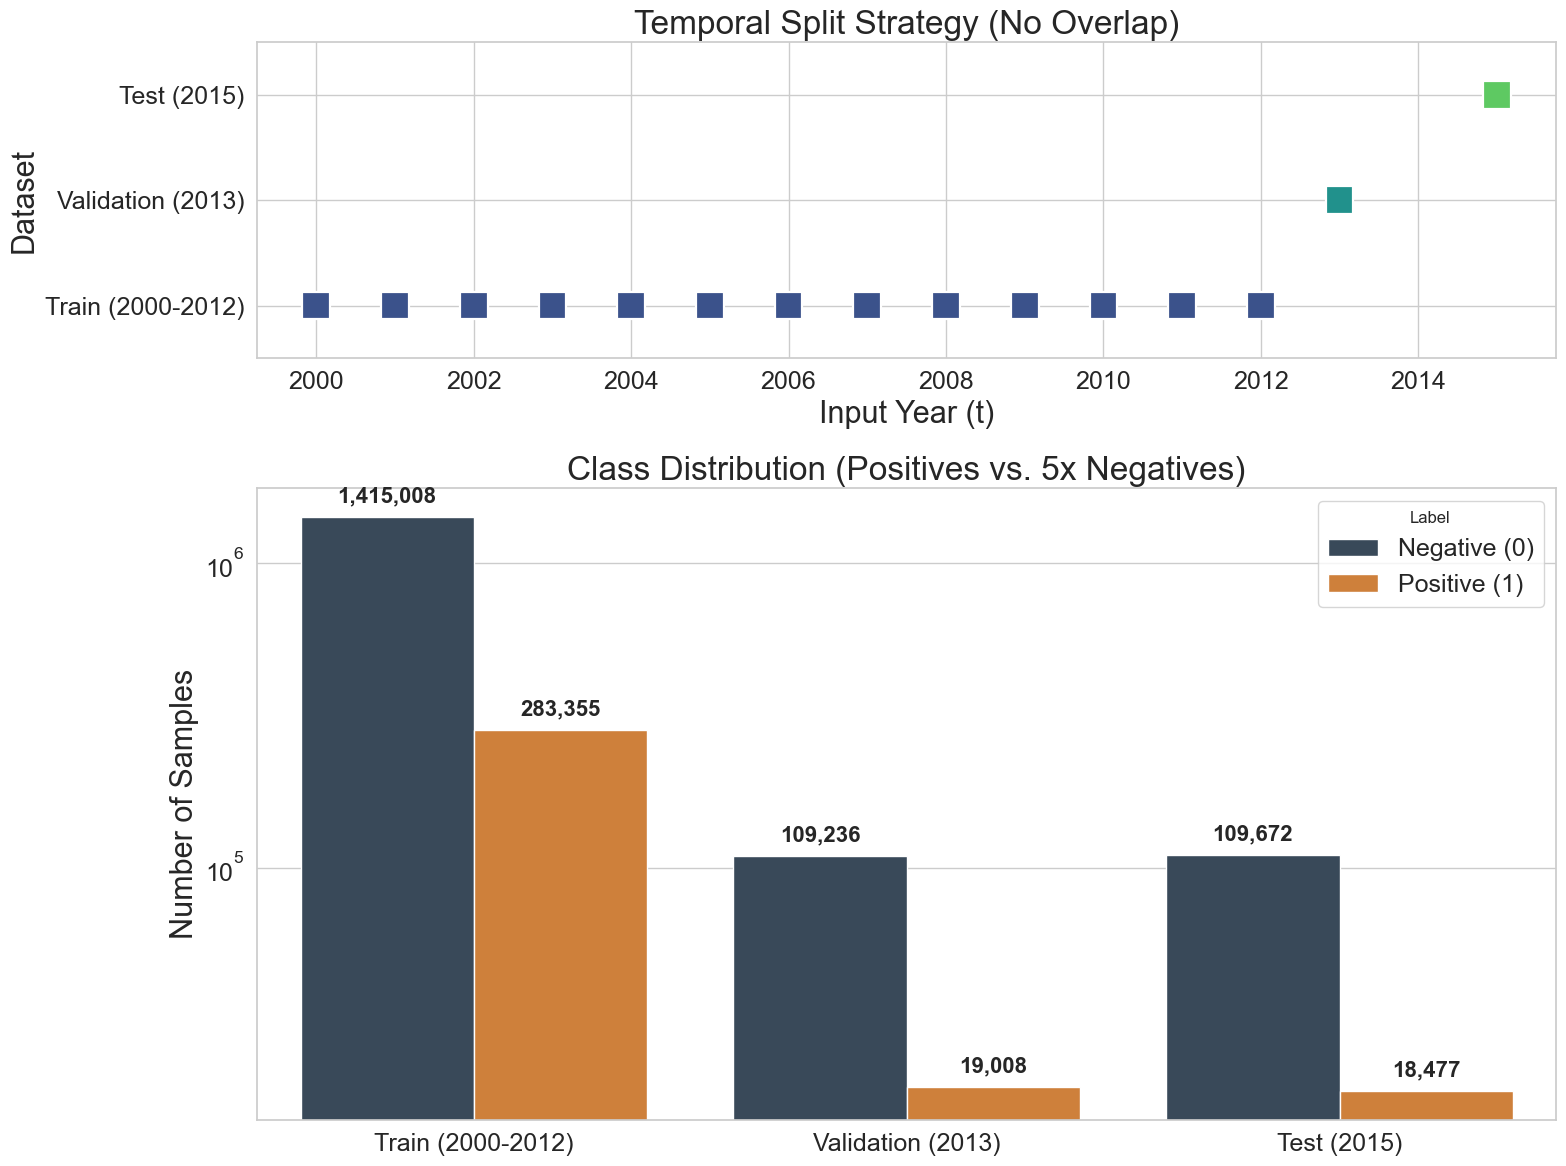

Dataset Summary Statistics:
Train (2000-2012): 1,698,363 total samples | 283,355 Pos, 1,415,008 Neg | Ratio: 5.0:1
Validation (2013): 128,244 total samples | 19,008 Pos, 109,236 Neg | Ratio: 5.7:1
Test (2015): 128,149 total samples | 18,477 Pos, 109,672 Neg | Ratio: 5.9:1


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style for academic-quality charts
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 18, 'axes.labelsize': 22, 'axes.titlesize': 24, 
                     'xtick.labelsize': 18, 'ytick.labelsize': 18, 'legend.fontsize': 18})

# 1. Load the generated split files
data_dir = "data"
splits = {
    'Train (2000-2012)': pd.read_csv(os.path.join(data_dir, "train_labels.csv")),
    'Validation (2013)': pd.read_csv(os.path.join(data_dir, "val_labels.csv")),
    'Test (2015)': pd.read_csv(os.path.join(data_dir, "test_labels.csv"))
}

# 2. Prepare data for plotting
plot_data = []
for name, df in splits.items():
    counts = df['label'].value_counts().to_dict()
    plot_data.append({'Split': name, 'Label': 'Negative (0)', 'Count': counts.get(0, 0)})
    plot_data.append({'Split': name, 'Label': 'Positive (1)', 'Count': counts.get(1, 0)})

summary_df = pd.DataFrame(plot_data)

# 3. Create Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [1, 2]})

# --- Subplot 1: Temporal Timeline ---
# Visualises which years belong to which dataset
timeline = []
for name, df in splits.items():
    years = sorted(df['year'].unique())
    timeline.append(pd.DataFrame({'Year': years, 'Dataset': name}))

timeline_df = pd.concat(timeline)
sns.scatterplot(data=timeline_df, x='Year', y='Dataset', hue='Dataset', 
                s=400, marker='s', legend=False, ax=ax1, palette='viridis')
ax1.set_title("Temporal Split Strategy (No Overlap)")
ax1.set_ylim(-0.5, 2.5)
ax1.set_xlabel("Input Year (t)")

# --- Subplot 2: Class Distribution ---
# Visualises the 5:1 ratio and total samples
sns.barplot(data=summary_df, x='Split', y='Count', hue='Label', 
            palette=['#34495e', '#e67e22'], ax=ax2)

# Add value labels on top of bars
for p in ax2.patches:
    if p.get_height() > 0:
        ax2.annotate(f'{int(p.get_height()):,}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 15), 
                    textcoords='offset points', fontsize=16, fontweight='bold')

ax2.set_title("Class Distribution (Positives vs. 5x Negatives)")
ax2.set_ylabel("Number of Samples")
ax2.set_yscale('log') # Log scale helps see small positive counts next to large negative counts
ax2.set_xlabel("")

plt.tight_layout()
plt.show()

# Print Summary Statistics
print("Dataset Summary Statistics:")
for name, df in splits.items():
    pos = (df['label'] == 1).sum()
    neg = (df['label'] == 0).sum()
    ratio = neg / pos if pos > 0 else 0
    print(f"{name}: {len(df):,} total samples | {pos:,} Pos, {neg:,} Neg | Ratio: {ratio:.1f}:1")


In [ ]:
import torch
import os
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from models import BipartiteEncoder, TemporalBipartiteGNN, LinkPredictor
from utils_metrics import binary_auc, precision_at_k, recall_at_k
import numpy as np

# Set seed for reproducibility
torch.manual_seed(42)

class TemporalDataset(Dataset):
    def __init__(self, data_list):
        # Handle case where val/test are single dicts instead of lists
        if isinstance(data_list, dict):
            self.data = [data_list]
        else:
            self.data = data_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

def collate_fn(batch):
    # Since batch_size=1, just return the first element
    return batch[0]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
# Step 1: Load data
print("Loading data...")
train_data = torch.load('data/train_data.pt', weights_only=False)
val_data = torch.load('data/val_data.pt', weights_only=False)
test_data = torch.load('data/test_data.pt', weights_only=False)
# To fix to_hetero node update issues, we must make snapshots undirected
import torch_geometric.transforms as T
to_undirected = T.ToUndirected()
def make_undirected(data_list):
    if isinstance(data_list, dict):
        # Val/Test
        data_list['snapshots'] = [to_undirected(s) for s in data_list['snapshots']]
    else:
        # Train
        for item in data_list:
            item['snapshots'] = [to_undirected(s) for s in item['snapshots']]
print("Converting snapshots to undirected for training...")
make_undirected(train_data)
make_undirected(val_data)
make_undirected(test_data)
train_loader = DataLoader(TemporalDataset(train_data), batch_size=1, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(TemporalDataset(val_data), batch_size=1, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(TemporalDataset(test_data), batch_size=1, shuffle=False, collate_fn=collate_fn)
# Infer input dimensions
sample_snapshot = train_data[0]['snapshots'][0]
country_in_dim = sample_snapshot['country'].x.size(1)
product_in_dim = sample_snapshot['product'].x.size(1)
metadata = sample_snapshot.metadata()

print(f"Metadata (Undirected): {metadata}")
print(f"Input dims: Country={country_in_dim}, Product={product_in_dim}")
# Step 2: Initialize model
hidden_dim = 128
temp_hidden_dim = 128

encoder = BipartiteEncoder(country_in_dim, product_in_dim, hidden_dim=hidden_dim, metadata=metadata)
model = TemporalBipartiteGNN(encoder, hidden_dim=hidden_dim, temporal_hidden_dim=temp_hidden_dim)
predictor = LinkPredictor(in_dim=temp_hidden_dim * 2, hidden_dim=128)
model = model.to(device)
predictor = predictor.to(device)
optimizer = torch.optim.Adam(
    list(model.parameters()) + list(predictor.parameters()), 
    lr=1e-3, weight_decay=1e-5
)
criterion = nn.BCEWithLogitsLoss()
checkpoint_dir = 'checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
best_val_auc = 0.0
print("Starting training loop...")
for epoch in range(1, 101):
    # TRAIN
    model.train()
    predictor.train()
    total_loss = 0
    
    for batch in train_loader:
        snapshots = [s.to(device) for s in batch['snapshots']]
        labels = batch['labels']
        edge_label_index = labels['edge_label_index'].to(device)
        edge_label = labels['edge_label'].to(device)
        optimizer.zero_grad()
        z_dict = model(snapshots)
        logits = predictor(z_dict['country'], z_dict['product'], edge_label_index)
        
        loss = criterion(logits, edge_label.float())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    # VALIDATE
    model.eval()
    predictor.eval()
    val_auc, val_p50, val_r50 = 0.0, 0.0, 0.0
    
    with torch.no_grad():
        for batch in val_loader:
            snapshots = [s.to(device) for s in batch['snapshots']]
            labels = batch['labels']
            edge_label_index = labels['edge_label_index'].to(device)
            edge_label = labels['edge_label']
            z_dict = model(snapshots)
            logits = predictor(z_dict['country'], z_dict['product'], edge_label_index)
            probs = torch.sigmoid(logits).cpu().numpy()
            y_true = edge_label.numpy()
            
            # Metrics
            val_auc = binary_auc(y_true, probs)
            val_p50 = precision_at_k(y_true, probs, k=50, edge_label_index=labels['edge_label_index'].numpy())
            val_r50 = recall_at_k(y_true, probs, k=50, edge_label_index=labels['edge_label_index'].numpy())
    print(f"Epoch {epoch:03d} | Loss: {avg_loss:.4f} | Val AUC: {val_auc:.4f} | Val P@50: {val_p50:.4f} | Val R@50: {val_r50:.4f}")
    # Save Best
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save({
            'model': model.state_dict(),
            'predictor': predictor.state_dict(),
            'epoch': epoch,
            'val_auc': best_val_auc
        }, os.path.join(checkpoint_dir, 'best_model.pt'))
# TEST
print("\nTraining complete. Evaluating on test set...")
checkpoint = torch.load(os.path.join(checkpoint_dir, 'best_model.pt'), weights_only=False)
model.load_state_dict(checkpoint['model'])
predictor.load_state_dict(checkpoint['predictor'])

model.eval()
predictor.eval()
test_auc, test_p50, test_r50 = 0.0, 0.0, 0.0

with torch.no_grad():
    for batch in test_loader:
        snapshots = [s.to(device) for s in batch['snapshots']]
        labels = batch['labels']
        edge_label_index = labels['edge_label_index'].to(device)
        edge_label = labels['edge_label']
        z_dict = model(snapshots)
        logits = predictor(z_dict['country'], z_dict['product'], edge_label_index)
        probs = torch.sigmoid(logits).cpu().numpy()
        y_true = edge_label.numpy()
        
        test_auc = binary_auc(y_true, probs)
        test_p50 = precision_at_k(y_true, probs, k=50, edge_label_index=labels['edge_label_index'].numpy())
        test_r50 = recall_at_k(y_true, probs, k=50, edge_label_index=labels['edge_label_index'].numpy())
print(f"BEST VAL AUC EPOCH: {checkpoint['epoch']}")
print(f"TEST METRICS: AUC = {test_auc:.4f}, P@50 = {test_p50:.4f}, R@50 = {test_r50:.4f}")
torch.save({'model': model.state_dict(), 'predictor': predictor.state_dict()}, 'checkpoints/final_weights.pt')

Using device: cuda
Loading data...
Converting snapshots to undirected for training...
Metadata (Undirected): (['country', 'product'], [('country', 'exports', 'product'), ('product', 'rev_exports', 'country')])
Input dims: Country=11, Product=3
Starting training loop...


C:\Users\Ashwa\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch_geometric\nn\to_hetero_transformer.py:120: UserWarning: Found function 'dropout' with keyword argument 'training'. During FX tracing, this will likely be baked in as a constant value. Consider replacing this function by a module to properly encapsulate its training flag.
  return transformer.transform()


Epoch 001 | Loss: 0.4789 | Val AUC: 0.7520 | Val P@50: 0.2905 | Val R@50: 0.2503
Epoch 002 | Loss: 0.3966 | Val AUC: 0.7746 | Val P@50: 0.2916 | Val R@50: 0.2510
Epoch 003 | Loss: 0.3804 | Val AUC: 0.7841 | Val P@50: 0.2918 | Val R@50: 0.2527
Epoch 004 | Loss: 0.3721 | Val AUC: 0.7858 | Val P@50: 0.3002 | Val R@50: 0.2611
Epoch 005 | Loss: 0.3692 | Val AUC: 0.7902 | Val P@50: 0.3092 | Val R@50: 0.2666
Epoch 006 | Loss: 0.3674 | Val AUC: 0.7936 | Val P@50: 0.3140 | Val R@50: 0.2690
Epoch 007 | Loss: 0.3656 | Val AUC: 0.7948 | Val P@50: 0.3215 | Val R@50: 0.2769
Epoch 008 | Loss: 0.3624 | Val AUC: 0.7994 | Val P@50: 0.3234 | Val R@50: 0.2765
Epoch 009 | Loss: 0.3597 | Val AUC: 0.8033 | Val P@50: 0.3235 | Val R@50: 0.2767
Epoch 010 | Loss: 0.3582 | Val AUC: 0.8037 | Val P@50: 0.3224 | Val R@50: 0.2769
Epoch 011 | Loss: 0.3581 | Val AUC: 0.8047 | Val P@50: 0.3259 | Val R@50: 0.2803
Epoch 012 | Loss: 0.3563 | Val AUC: 0.8043 | Val P@50: 0.3265 | Val R@50: 0.2800
Epoch 013 | Loss: 0.3556 | V

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, f1_score
import numpy as np

def evaluate_model_performance(y_true, y_probs, title_suffix=""):
    """
    Calculates F1-score and plots ROC-AUC + Precision-Recall curves.
    Designed for high-visibility (large fonts) as per research requirements.
    """
    # 1. Calculate Optimal F1-Score (find the best threshold)
    precision, recall, thresholds = precision_recall_curve(y_true, y_probs)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    best_f1 = f1_scores[best_idx]
    
    # 2. Calculate AUCs
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    avg_precision = average_precision_score(y_true, y_probs)

    # 3. Setup Plotting (Premium Styling & Large Fonts)
    plt.style.use('dark_background')
    plt.rcParams.update({'font.size': 18}) # Large base font
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))
    
    # --- ROC CURVE ---
    ax1.plot(fpr, tpr, color='#00d2ff', lw=4, label=f'ROC (AUC = {roc_auc:.3f})')
    ax1.plot([0, 1], [0, 1], color='white', lw=2, linestyle='--', alpha=0.5)
    ax1.set_xlim([-0.02, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate', fontsize=22, fontweight='bold')
    ax1.set_ylabel('True Positive Rate', fontsize=22, fontweight='bold')
    ax1.set_title(f'ROC Curve {title_suffix}', fontsize=26, fontweight='bold', pad=25)
    ax1.legend(loc="lower right", fontsize=18)
    ax1.grid(alpha=0.2)

    # --- PRECISION-RECALL CURVE ---
    ax2.plot(recall, precision, color='#ff006e', lw=4, label=f'Avg Precision = {avg_precision:.3f}')
    ax2.set_xlabel('Recall (Sensitivity)', fontsize=22, fontweight='bold')
    ax2.set_ylabel('Precision', fontsize=22, fontweight='bold')
    ax2.set_title(f'Precision-Recall Curve {title_suffix}', fontsize=26, fontweight='bold', pad=25)
    ax2.legend(loc="lower left", fontsize=18)
    ax2.grid(alpha=0.2)
    
    # Annotate Optimal F1
    ax2.plot(recall[best_idx], precision[best_idx], 'wo', markersize=12)
    ax2.annotate(f'Best F1: {best_f1:.3f}\nThr: {best_threshold:.2f}', 
                 (recall[best_idx], precision[best_idx]),
                 xytext=(10, 10), textcoords='offset points',
                 fontsize=18, color='white', fontweight='bold')

    plt.tight_layout()
    plt.show()

    print(f"--- Evaluation Summary ---")
    print(f"ROC-AUC:         {roc_auc:.4f}")
    print(f"Avg Precision:   {avg_precision:.4f}")
    print(f"Optimal F1:      {best_f1:.4f} (at threshold {best_threshold:.4f})")
    
    return {
        'roc_auc': roc_auc,
        'avg_precision': avg_precision,
        'best_f1': best_f1,
        'best_threshold': best_threshold
    }


In [ ]:
import torch
from models import BipartiteEncoder, TemporalBipartiteGNN, LinkPredictor

# 1. Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Get dimensions from your data (metadata and input dims are required to build the model)
# We use the first snapshot of your test_data to find these
sample_snapshot = test_data[0]['snapshots'][0]
country_in_dim = sample_snapshot['country'].x.size(1)
product_in_dim = sample_snapshot['product'].x.size(1)
metadata = sample_snapshot.metadata()

# 3. RE-INITIALIZE THE MODEL ARCHITECTURE
hidden_dim = 128
temp_hidden_dim = 128

encoder = BipartiteEncoder(country_in_dim, product_in_dim, hidden_dim=hidden_dim, metadata=metadata)
model = TemporalBipartiteGNN(encoder, hidden_dim=hidden_dim, temporal_hidden_dim=temp_hidden_dim)
predictor = LinkPredictor(in_dim=temp_hidden_dim * 2, hidden_dim=128)

model = model.to(device)
predictor = predictor.to(device)

# 4. NOW LOAD THE CHECKPOINT
checkpoint = torch.load('checkpoints/GNN/best_model.pt', weights_only=False)
model.load_state_dict(checkpoint['model'])
predictor.load_state_dict(checkpoint['predictor'])

model.eval()
predictor.eval()
print("Model re-initialized and weights loaded successfully!")


KeyError: 0

Loading test data for final evaluation...


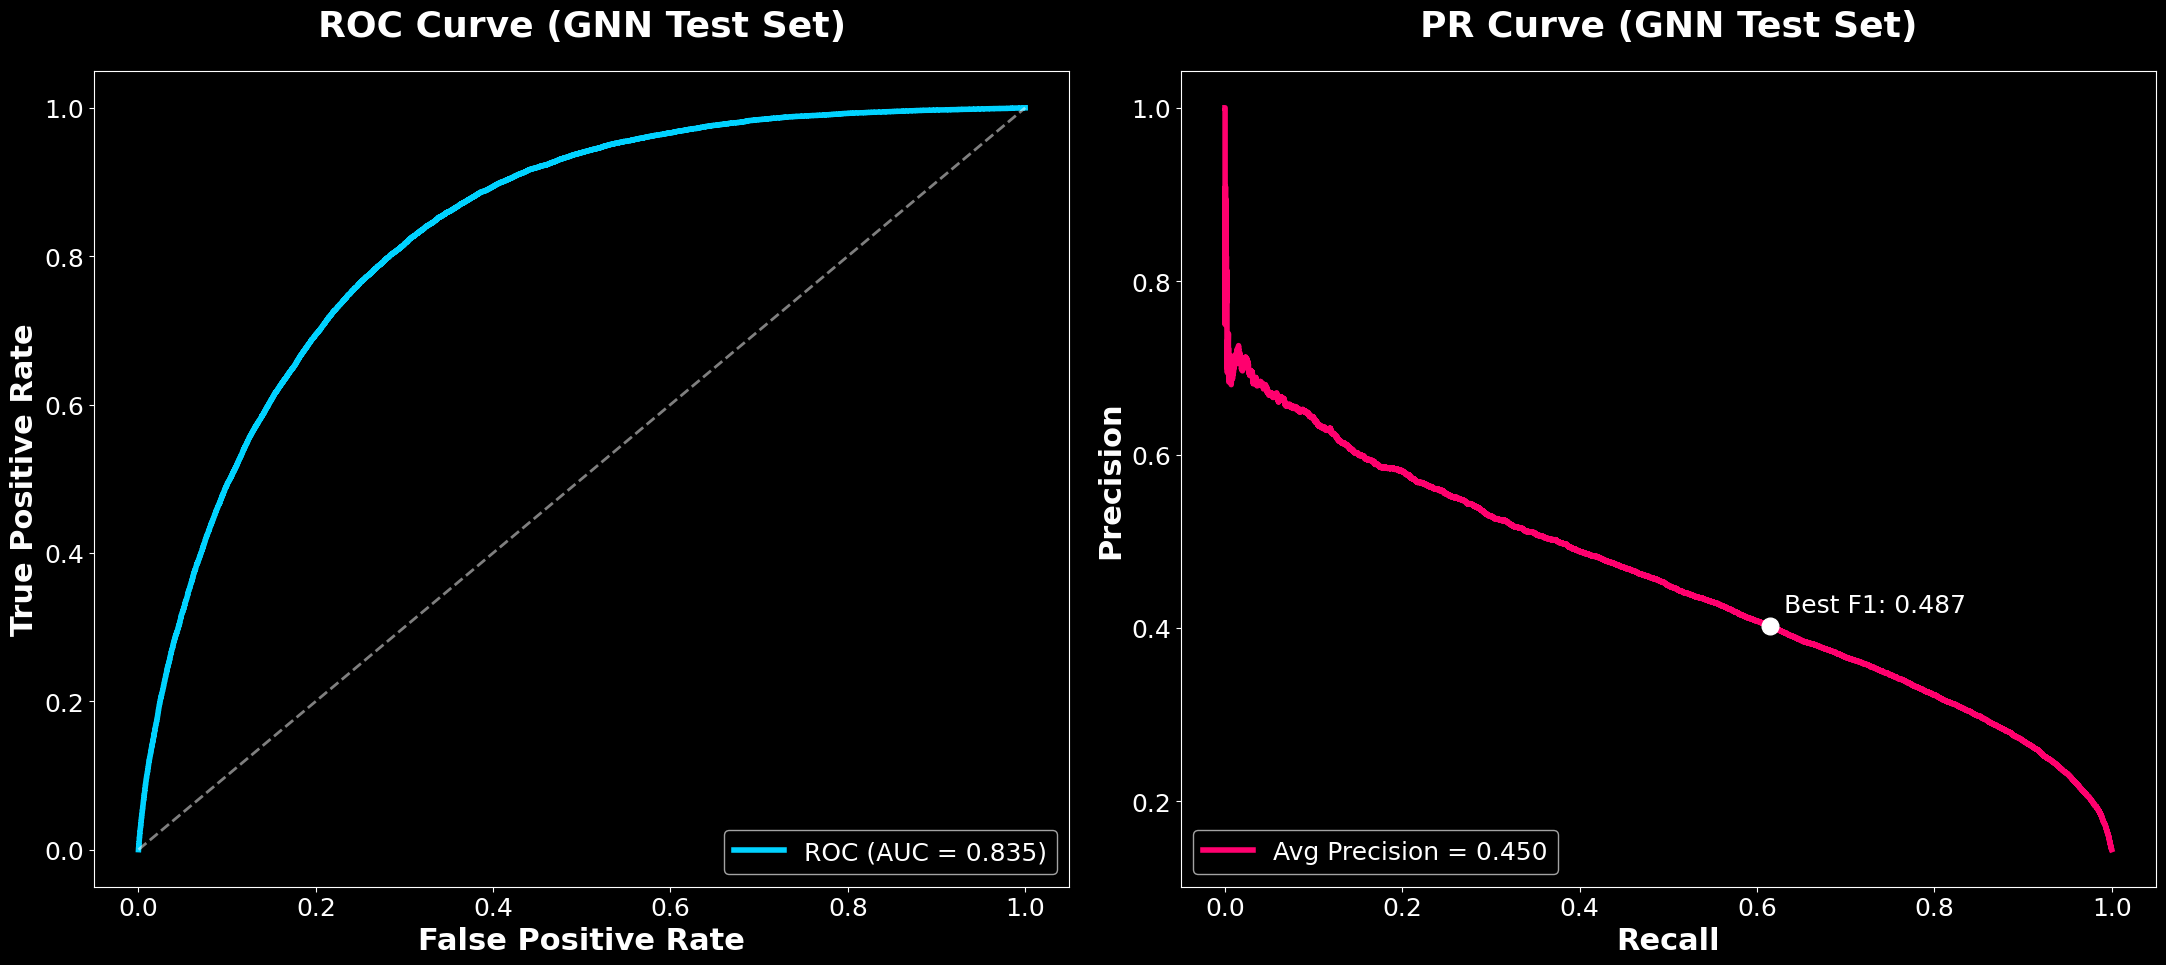

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# ==========================================
# 1. THE EVALUATION FUNCTION
# ==========================================
def evaluate_model_performance(y_true, y_probs, title_suffix=""):
    precision, recall, thresholds = precision_recall_curve(y_true, y_probs)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    best_f1 = f1_scores[best_idx]
    
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    avg_precision = average_precision_score(y_true, y_probs)

    plt.style.use('dark_background')
    plt.rcParams.update({'font.size': 18})
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))
    
    # ROC Plot
    ax1.plot(fpr, tpr, color='#00d2ff', lw=4, label=f'ROC (AUC = {roc_auc:.3f})')
    ax1.plot([0, 1], [0, 1], color='white', lw=2, linestyle='--', alpha=0.5)
    ax1.set_xlabel('False Positive Rate', fontsize=22, fontweight='bold')
    ax1.set_ylabel('True Positive Rate', fontsize=22, fontweight='bold')
    ax1.set_title(f'ROC Curve {title_suffix}', fontsize=26, fontweight='bold', pad=25)
    ax1.legend(loc="lower right")

    # Precision-Recall Plot
    ax2.plot(recall, precision, color='#ff006e', lw=4, label=f'Avg Precision = {avg_precision:.3f}')
    ax2.set_xlabel('Recall', fontsize=22, fontweight='bold')
    ax2.set_ylabel('Precision', fontsize=22, fontweight='bold')
    ax2.set_title(f'PR Curve {title_suffix}', fontsize=26, fontweight='bold', pad=25)
    ax2.legend(loc="lower left")
    
    # Highlight Best F1
    ax2.plot(recall[best_idx], precision[best_idx], 'wo', markersize=12)
    ax2.annotate(f'Best F1: {best_f1:.3f}', (recall[best_idx], precision[best_idx]), 
                 xytext=(10, 10), textcoords='offset points', fontsize=18, color='white')

    plt.tight_layout()
    plt.show()
    return {'auc': roc_auc, 'ap': avg_precision, 'f1': best_f1}

# ==========================================
# 2. RUNNING THE EVALUATION
# ==========================================
# Re-setup device (Variables inside train() are local, so we redefine them here)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load only the Test Data
print("Loading test data for final evaluation...")
test_data = torch.load('data/test_data.pt', weights_only=False)

# Re-apply the Undirected transform (matches your train() logic)
import torch_geometric.transforms as T
to_undirected = T.ToUndirected()
if isinstance(test_data, dict):
    test_data['snapshots'] = [to_undirected(s) for s in test_data['snapshots']]

test_loader = DataLoader(TemporalDataset(test_data), batch_size=1, shuffle=False, collate_fn=collate_fn)

# Load the Best Checkpoint
checkpoint = torch.load('checkpoints/GNN/best_model.pt', weights_only=False)
model.load_state_dict(checkpoint['model'])
predictor.load_state_dict(checkpoint['predictor'])

model.eval()
predictor.eval()

# Generate Test Predictions
all_probs = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        snapshots = [s.to(device) for s in batch['snapshots']]
        labels = batch['labels']
        edge_label_index = labels['edge_label_index'].to(device)
        
        z_dict = model(snapshots)
        logits = predictor(z_dict['country'], z_dict['product'], edge_label_index)
        probs = torch.sigmoid(logits).cpu().numpy()
        
        all_probs.extend(probs)
        all_labels.extend(labels['edge_label'].numpy())

# Final Output
results = evaluate_model_performance(np.array(all_labels), np.array(all_probs), title_suffix="(GNN Test Set)")
